In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [42]:
# Load the approx algorithms dataset
columns = [
    'Family Name', 
    'Variation',
    'Algorithm Name', 
    'Year',
    'Looked at?',
    'Use For Inapprox?',
    'Parallel?',
    'Time Complexity Class',
    'Approximation Factor Class (Mult)', 
    'Approximation Factor Class (Add)',
    'Approximation Type (additive/multiplicative)',	
    'Approximation Factor (if approximate algorithm)',
    'Time Complexity (Worst Only)',
    'Parametrized Approximation?',
    'Type of PTAS (if PTAS)',
    'Quantum?'
]
approximation_algorithms = pd.read_csv('approx_algos.csv', usecols=columns)

# Clean and prepare the data
# drop Looked at? == 0.001 or 0
approximation_algorithms = approximation_algorithms[approximation_algorithms['Looked at?'] != '0.001']
approximation_algorithms = approximation_algorithms[approximation_algorithms['Looked at?'] != '0']

# drop Relevant? == 0
# approximation_algorithms = approximation_algorithms[approximation_algorithms['Use For Inapprox?'] != 0]
# approximation_algorithms = approximation_algorithms[approximation_algorithms['Use For Inapprox?'] != '0']

# filter out parallel algorithms
approximation_algorithms = approximation_algorithms[approximation_algorithms['Parallel?'] != '1']

approximation_algorithms = approximation_algorithms[approximation_algorithms['Quantum?'] != '1']
approximation_algorithms = approximation_algorithms[approximation_algorithms['Quantum?'] != 1]






approximation_algorithms['Year'] = pd.to_numeric(approximation_algorithms['Year'].str.extract(r'(\d{4})')[0], errors='coerce')
approximation_algorithms.dropna(subset=['Year'], inplace=True)
# approximation_algorithms['Year'] = approximation_algorithms['Year'].astype(int)

# drop empty family names
approximation_algorithms = approximation_algorithms[approximation_algorithms['Family Name'].notnull()]

for col in ['Time Complexity Class', 'Approximation Factor Class (Mult)', 'Approximation Factor Class (Add)']:
    # Extract numeric (float) from string
    approximation_algorithms[col] = approximation_algorithms[col].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
    approximation_algorithms[col] = approximation_algorithms[col].replace(0, 99999)
    

approximation_algorithms.sort_values(by=['Family Name', 'Year', 'Variation'], inplace=True)

approximation_algorithms

,Family Name,Looked at?,Use For Inapprox?,Variation,Algorithm Name,Year,Time Complexity Class,Time Complexity (Worst Only),Approximation Factor (if approximate algorithm),Approximation Factor Class (Mult),Approximation Factor Class (Add),Approximation Type (additive/multiplicative),Parametrized Approximation?,Type of PTAS (if PTAS),Parallel?,Quantum?
148,All-Pairs Shortest Paths (APSP),1,0,"APSP, weighted, undirected, no FMM (Approximate)","Awerbuch, Berger, Cohen, Peleg",1993.0,5.01,O(mt+nt^2)n^(64/t)(log n)+tn^(2+32/t)(log log n)),t,6.00,99999.0,multiplicative,yes,NaN,0,0.0
149,All-Pairs Shortest Paths (APSP),1,0,"APSP, weighted, undirected, no FMM (Approximate)",Cohen,1993.0,5.01,O(n^(2+(2+eps)/(t+eps))*poly(log(n))),t + eps,6.00,99999.0,multiplicative,yes,NaN,0,0.0
150,All-Pairs Shortest Paths (APSP),1,0,"APSP, weighted, undirected, no FMM (Approximate)",Cohen,1993.0,5.01,O(n^(2+2(1+eps+log(m)/log(n))/(t+eps))*poly(lo...,t + eps,6.00,99999.0,multiplicative,yes,NaN,0,0.0
154,All-Pairs Shortest Paths (APSP),1,0,"APSP, unweighted, undirected, no FMM (Approxim...","Aingworth, Chekuri, Indyk, Motwani",1999.0,5.50,O(n^2.5 sqrt(log n)),2,99999.00,2.0,additive,no,NaN,0,0.0
155,All-Pairs Shortest Paths (APSP),1,0,"APSP, unweighted, undirected, no FMM (Approxim...","Dor, Halperin, Zwick [APASP_2]",2000.0,5.33,"O(min(n^(3/2)m^(1/2), n^(7/3))*poly(log n))",2,99999.00,2.0,additive,no,NaN,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,k Minimum Spanning Tree (k-MST),1,0,Euclidean k-MST (Approximate),Arora [Derandomized],1998.0,7.00,O(V^(d+1)k (log V)^(O(c*sqrt(d))^(d-1))),1+eps,2.00,99999.0,multiplicative,yes,EPTAS?,0,0.0
115,k Minimum Spanning Tree (k-MST),1,0,"General k-MST, unrooted (Approximate)","Arya, Ramesh",1998.0,7.00,O(poly(V)),2.5,4.00,99999.0,multiplicative,no,NaN,0,0.0
129,k Minimum Spanning Tree (k-MST),1,0,Euclidean k-MST (Approximate),Mitchell,1999.0,7.00,O(V^(O(m)))?,1+eps,2.00,99999.0,multiplicative,yes,PTAS,0,0.0
116,k Minimum Spanning Tree (k-MST),1,0,General k-MST (Approximate),"Arora, Karakostas",2000.0,7.00,V^(O(1/eps)),2+eps,3.01,99999.0,multiplicative,yes,NaN,0,0.0


In [43]:
# filter out only ptas algorithms
approximation_algorithms = approximation_algorithms[approximation_algorithms["Approximation Factor Class (Mult)"] == 2]
approximation_algorithms = approximation_algorithms[approximation_algorithms["Approximation Factor Class (Add)"] >= 1000]
# only 1+eps for now
approximation_algorithms = approximation_algorithms[approximation_algorithms["Approximation Factor (if approximate algorithm)"] == '1+eps']
approximation_algorithms

,Family Name,Looked at?,Use For Inapprox?,Variation,Algorithm Name,Year,Time Complexity Class,Time Complexity (Worst Only),Approximation Factor (if approximate algorithm),Approximation Factor Class (Mult),Approximation Factor Class (Add),Approximation Type (additive/multiplicative),Parametrized Approximation?,Type of PTAS (if PTAS),Parallel?,Quantum?
440,Cardinality Estimation,2,0,NaN,HyperLogLog algorithm,2007.0,3.00,O(N),1+eps,2.0,99999.0,multiplicative,yes,FPTAS,0,0.0
444,Cardinality Estimation,2,0,streaming,"Kane, Nelson, Woodruff",2010.0,3.00,O(N),1+eps,2.0,99999.0,multiplicative,yes,FPTAS,0,0.0
441,Cardinality Estimation,2,0,NaN,HyperLogLog++,2014.0,3.00,O(N),1+eps,2.0,99999.0,multiplicative,yes,FPTAS,0,0.0
963,Interval Scheduling,1,0,1|r_j|sum w_j(1-U_j) with equal additive laxity,NaN,2021.0,7.00,"O(poly(n, 1/eps))",1+eps,2.0,99999.0,multiplicative,yes,FPTAS,0,0.0
871,Link Analysis,1,0,Link Analysis,NaN,2014.0,4.66,O(n^(5/3) (log n)^(1/3) 1/eps sqrt(log(1/eps))),1+eps,2.0,99999.0,multiplicative,yes,FPRAS,0,0.0
1006,Maximum Disjoint Set,1,0,MDS/Independent Set for Unit Balls,"Hochbaum, Maass",1985.0,7.00,n^(O(1/eps^d)),1+eps,2.0,99999.0,multiplicative,yes,PTAS,0,0.0
1007,Maximum Disjoint Set,1,0,MDS/Independent Set for Unit Hypercubes,"Hochbaum, Maass",1985.0,7.00,n^(O(1/eps^d)),1+eps,2.0,99999.0,multiplicative,yes,PTAS,0,0.0
1033,Maximum Disjoint Set,1,0,MDS/Independent Set for Fat Objects of Varying...,"Erlebach, Jansen, Seidel",2002.0,7.00,n^(O(1/eps^d)),1+eps,2.0,99999.0,multiplicative,yes,PTAS,0,0.0
1034,Maximum Disjoint Set,2,0,MDS/Independent Set for Fat Objects of Varying...,Chan,2003.0,7.00,n^(O(1/eps^(d-1))),1+eps,2.0,99999.0,multiplicative,yes,PTAS,0,0.0
1035,Maximum Disjoint Set,2,0,MDS/Independent Set for Fat Objects of Varying...,Chan,2003.0,7.00,n^(O(1/eps^d)),1+eps,2.0,99999.0,multiplicative,yes,PTAS,0,0.0


In [44]:
tsp = approximation_algorithms[approximation_algorithms['Family Name'] == 'The Traveling-Salesman Problem']
tsp = tsp[tsp['Variation'] == 'Approximate Geometric TSP']
tsp


,Family Name,Looked at?,Use For Inapprox?,Variation,Algorithm Name,Year,Time Complexity Class,Time Complexity (Worst Only),Approximation Factor (if approximate algorithm),Approximation Factor Class (Mult),Approximation Factor Class (Add),Approximation Type (additive/multiplicative),Parametrized Approximation?,Type of PTAS (if PTAS),Parallel?,Quantum?
501,The Traveling-Salesman Problem,1,0,Approximate Geometric TSP,Karp [Algorithm 1],1977.0,4.0,O((C^t)/t * V + V log V),1+eps,2.0,99999.0,multiplicative,yes,EPTAS,0,0.0
503,The Traveling-Salesman Problem,1,0,Approximate Geometric TSP,Arora,1996.0,8.0,"V^(O((log V)^(d-2)*(log log V)^(min(1, d-2)))/...",1+eps,2.0,99999.0,multiplicative,yes,QPTAS,0,0.0
504,The Traveling-Salesman Problem,1,0,Approximate Geometric TSP,Arora,1998.0,4.0,O(V (log V)^(O(c*sqrt(d))^(d-1))),1+eps,2.0,99999.0,multiplicative,yes,EPRAS?,0,0.0
505,The Traveling-Salesman Problem,1,0,Approximate Geometric TSP,Arora [Derandomized],1998.0,7.0,O(V^(d+1) (log V)^(O(c*sqrt(d))^(d-1))),1+eps,2.0,99999.0,multiplicative,yes,EPTAS?,0,0.0
507,The Traveling-Salesman Problem,2,0,Approximate Geometric TSP,"Rao, Smith [Monte Carlo Algorithm]",1998.0,4.0,(c*sqrt(d))^(O(d(c*sqrt(d))^(d-1))*V + O(dV lo...,1+eps,2.0,99999.0,multiplicative,yes,EPTAS,0,0.0
508,The Traveling-Salesman Problem,2,0,Approximate Geometric TSP,"Rao, Smith [Las Vegas Algorithm]",1998.0,4.0,2^((cd)^(O(d)))*V+O(dV log V),1+eps,2.0,99999.0,multiplicative,yes,EPTAS,0,0.0
509,The Traveling-Salesman Problem,2,0,Approximate Geometric TSP,"Rao, Smith [Derandomized Algorithm]",1998.0,4.0,2^((cd)^(O(d)))*V+(cd)^(O(d))*V log V,1+eps,2.0,99999.0,multiplicative,yes,EPTAS,0,0.0
506,The Traveling-Salesman Problem,1,0,Approximate Geometric TSP,Mitchell,1999.0,7.0,O(V^(20m+5)),1+eps,2.0,99999.0,multiplicative,yes,PTAS,0,0.0
510,The Traveling-Salesman Problem,1,0,Approximate Geometric TSP,"Bartal, Gottlieb",2013.0,3.0,2^((d/eps)^(O(d)))*V,1+eps,2.0,99999.0,multiplicative,yes,EPTAS,0,0.0
511,The Traveling-Salesman Problem,1,0,Approximate Geometric TSP,"Kisfaludi-Bak, Nederlof, Wegrzycki",2021.0,4.0,2^((poly(d)/eps)^(d-1))*V + poly(1/eps)*V log V,1+eps,2.0,99999.0,multiplicative,yes,EPTAS,0,0.0


{1977.0: 31.10299956639811, 1996.0: 99.50950039097326, 1998.0: 17.121084805585564, 1999.0: 1712.0562748477141, 2013.0: 123.41199826559247}


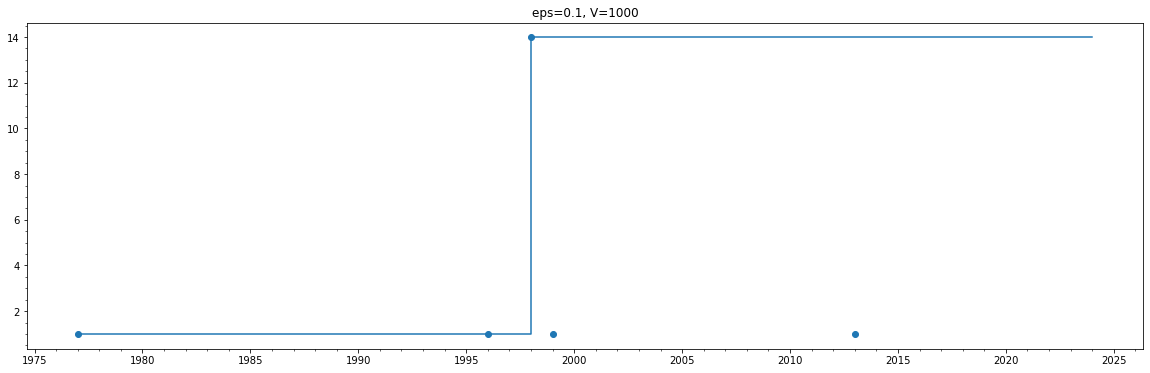

{1977.0: 34.10299956639811, 1996.0: 259.0190007819465, 1998.0: 24.378291831076726, 1999.0: 3424.1125496954282, 2013.0: 126.41199826559247}


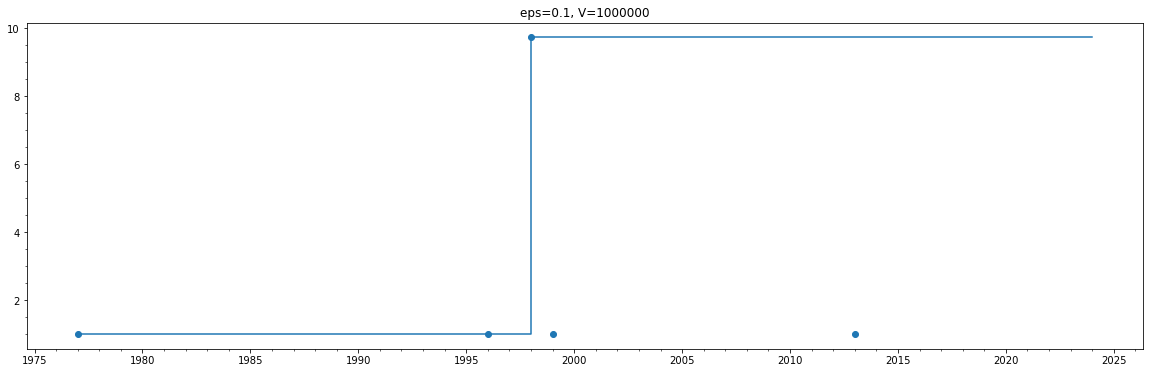

{1977.0: 37.10299956639811, 1996.0: 441.17512623782386, 1998.0: 29.868598298795714, 1999.0: 5136.168824543142, 2013.0: 129.41199826559247}


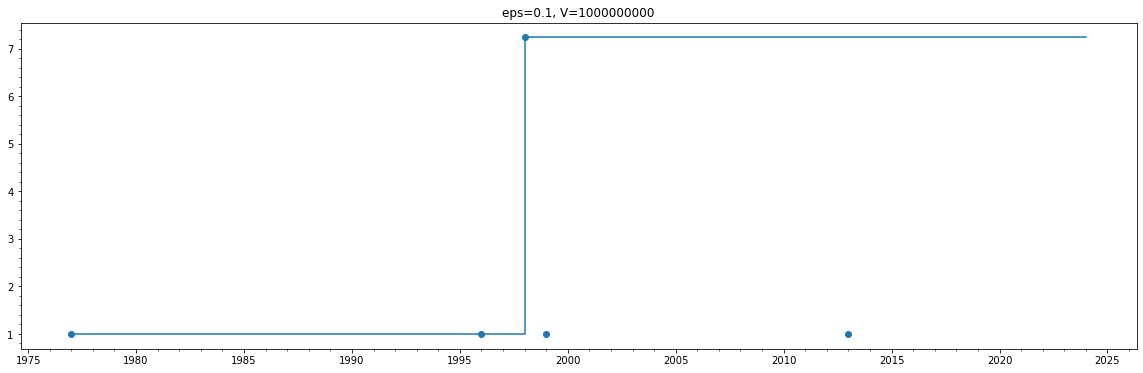

{1977.0: 3009.299956639812, 1996.0: 995.0950039097327, 1998.0: 144.21084805585565, 1999.0: 16985.56274847714, 2013.0: 12044.199826559248}


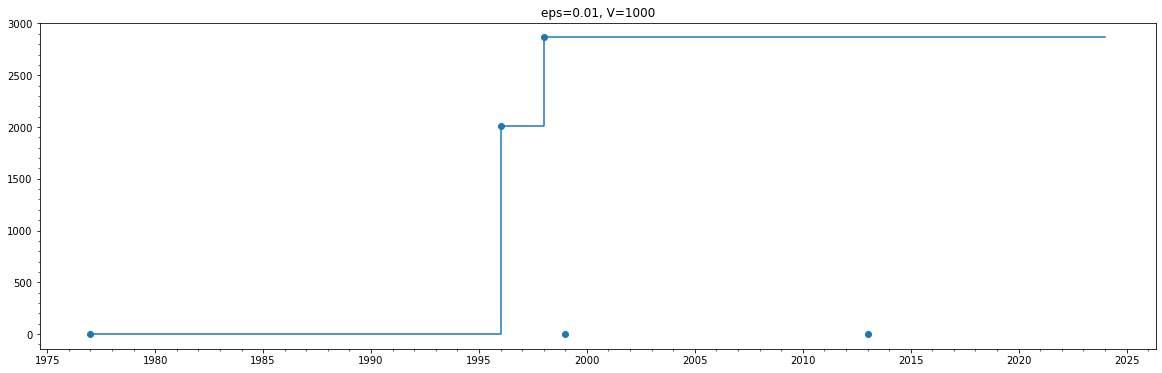

{1977.0: 3012.299956639812, 1996.0: 2590.1900078194653, 1998.0: 189.78291831076726, 1999.0: 33971.12549695428, 2013.0: 12047.199826559248}


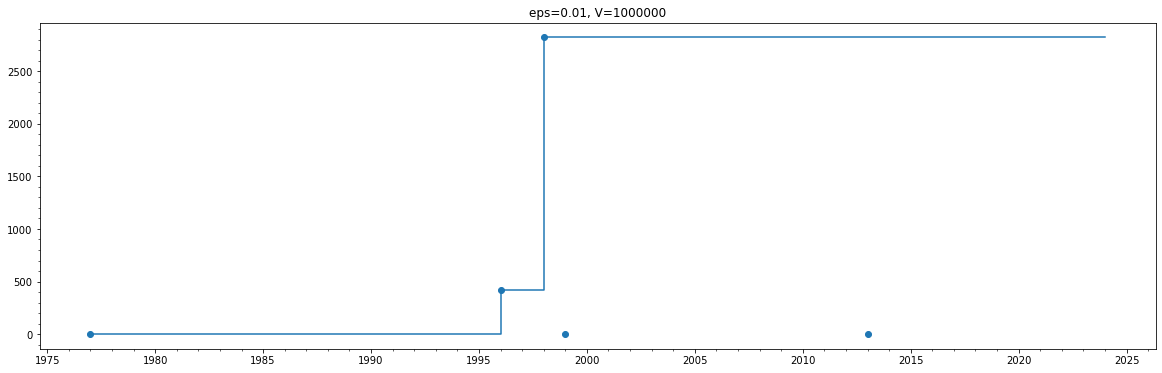

{1977.0: 3015.299956639812, 1996.0: 4411.751262378239, 1998.0: 217.68598298795712, 1999.0: 50956.688245431425, 2013.0: 12050.199826559248}


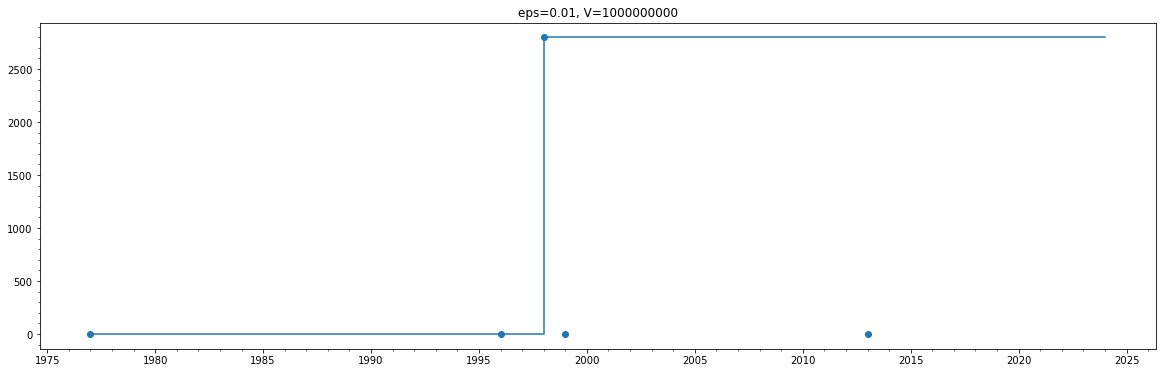

{1977.0: 301026.9956639812, 1996.0: 9950.950039097326, 1998.0: 1415.1084805585565, 1999.0: 169720.6274847714, 2013.0: 1204122.9826559247}


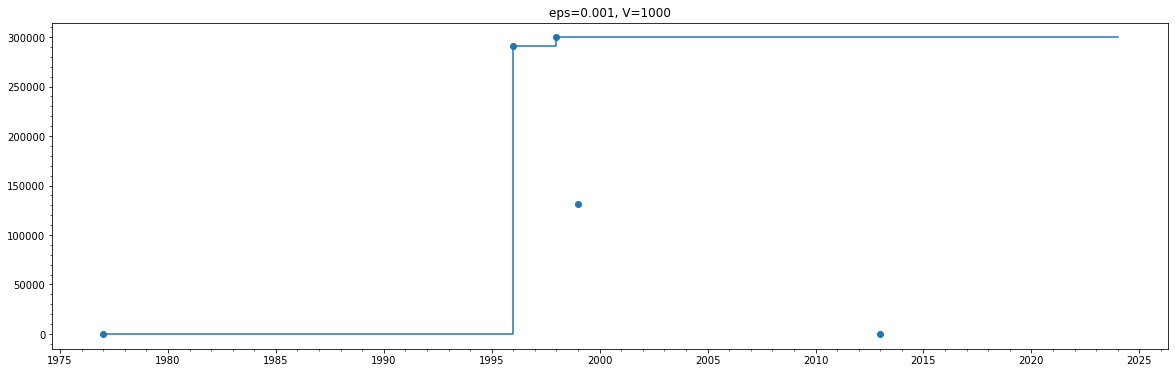

{1977.0: 301029.9956639812, 1996.0: 25901.900078194652, 1998.0: 1843.8291831076726, 1999.0: 339441.2549695428, 2013.0: 1204125.9826559247}


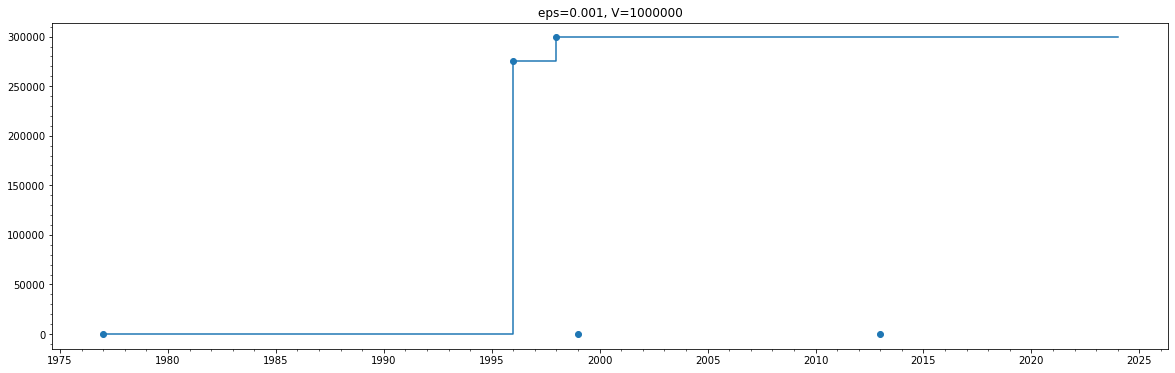

{1977.0: 301032.9956639812, 1996.0: 44117.51262378238, 1998.0: 2095.8598298795714, 1999.0: 509161.8824543142, 2013.0: 1204128.9826559247}


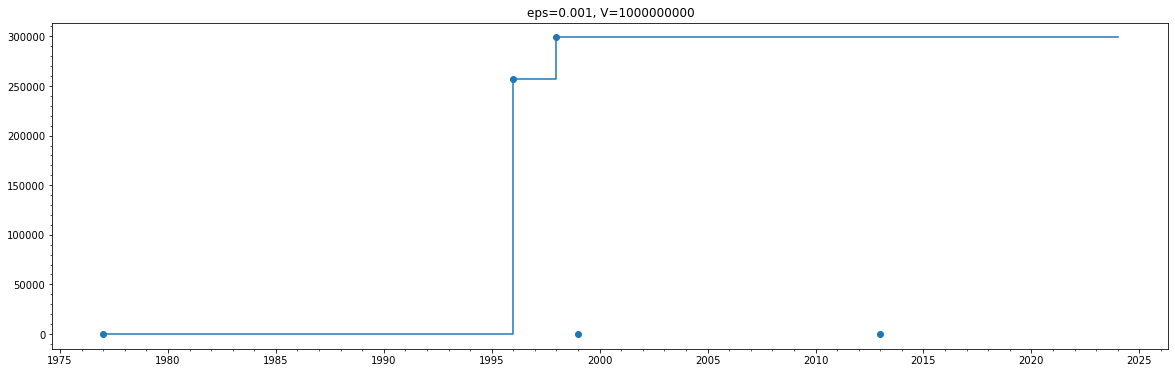

{1977.0: 30102994.566398114, 1996.0: 99509.50039097326, 1998.0: 14124.084805585564, 1999.0: 1697071.2748477138, 2013.0: 120412001.26559249}


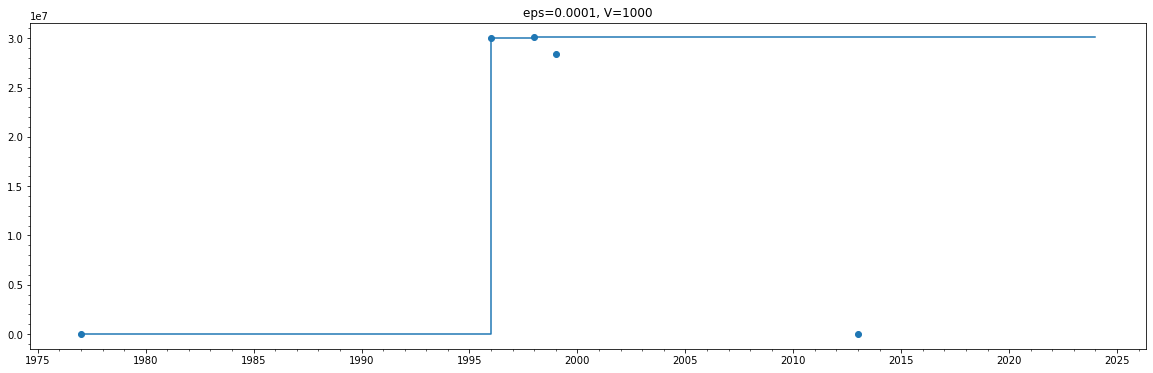

{1977.0: 30102997.566398114, 1996.0: 259019.00078194652, 1998.0: 18384.291831076724, 1999.0: 3394142.5496954275, 2013.0: 120412004.26559249}


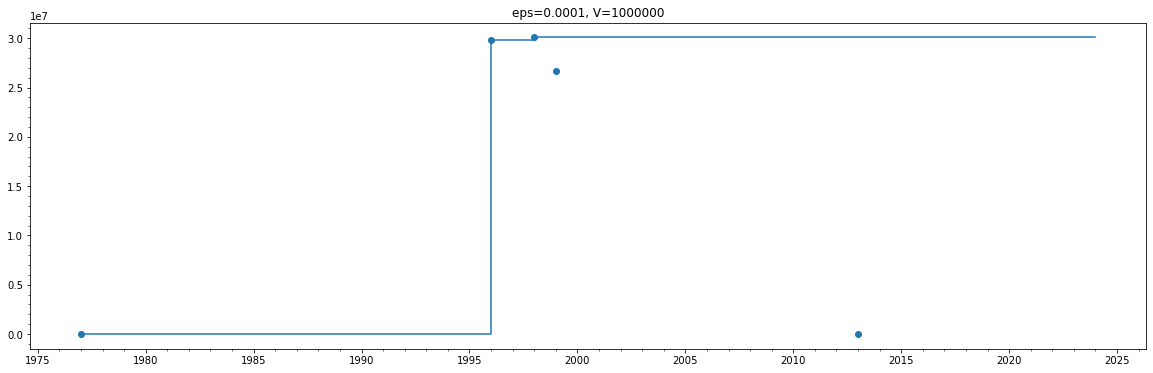

{1977.0: 30103000.566398114, 1996.0: 441175.12623782386, 1998.0: 20877.59829879571, 1999.0: 5091213.824543142, 2013.0: 120412007.26559249}


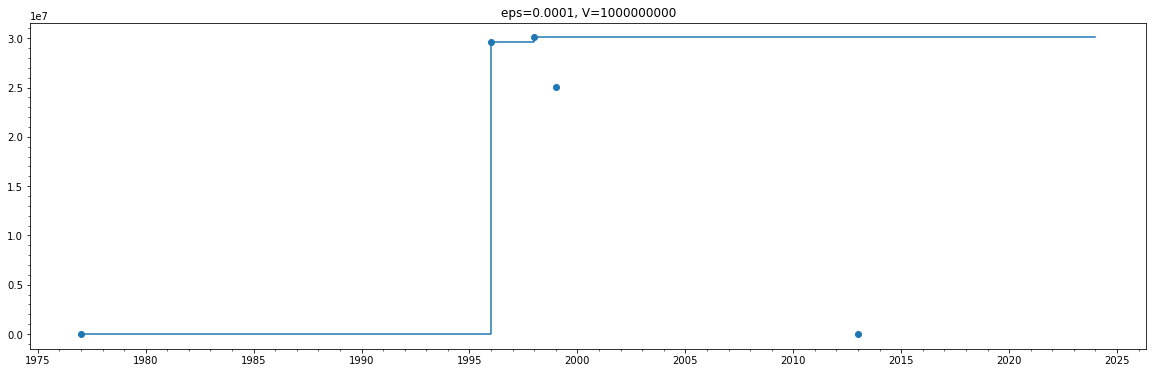

{1977.0: 3010299949.6398115, 1996.0: 995095.0039097326, 1998.0: 141213.84805585563, 1999.0: 16970577.74847714, 2013.0: 12041199829.559244}


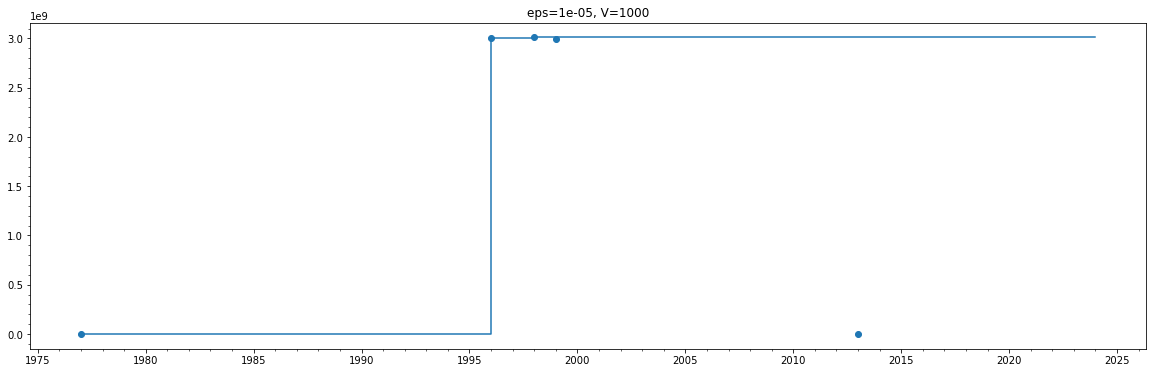

{1977.0: 3010299952.6398115, 1996.0: 2590190.0078194654, 1998.0: 183788.91831076724, 1999.0: 33941155.49695428, 2013.0: 12041199832.559244}


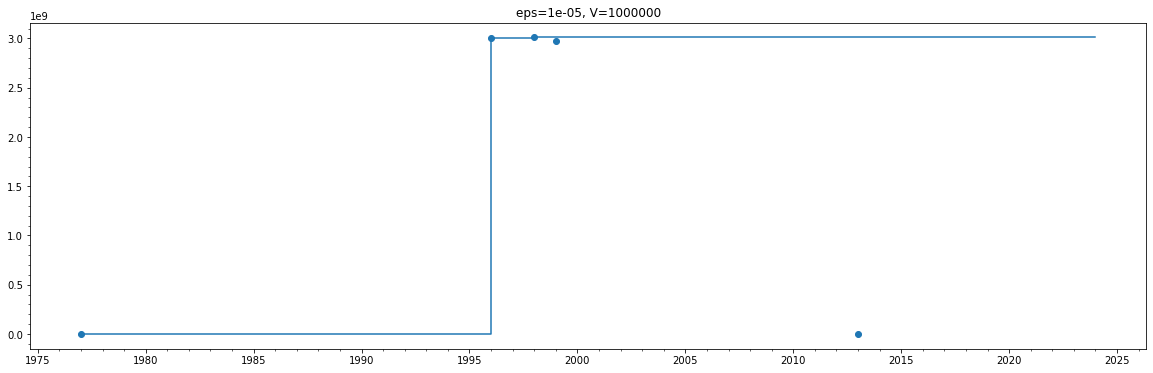

{1977.0: 3010299955.6398115, 1996.0: 4411751.262378238, 1998.0: 208694.9829879571, 1999.0: 50911733.245431416, 2013.0: 12041199835.559244}


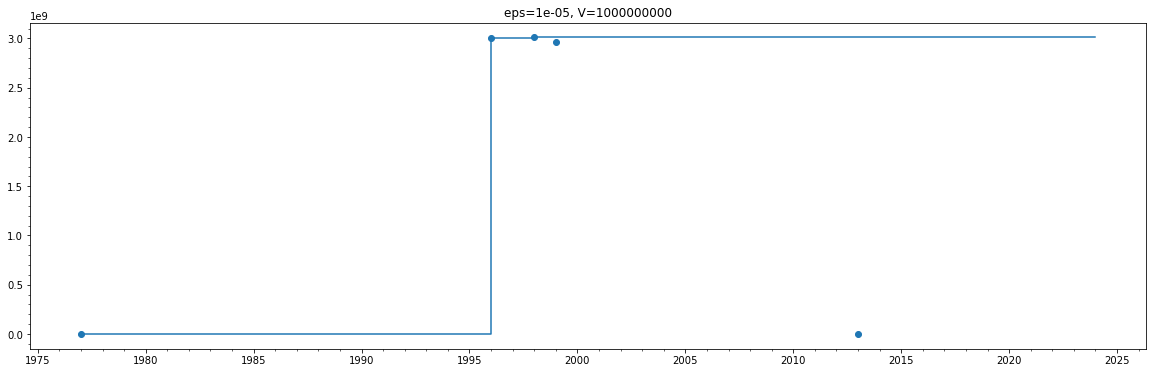

In [92]:

runtime_funcs_logs = {
  501: lambda eps, V, d, C, **kwargs: np.log10(V) + np.log10(C)*(eps**(-d/(d-1)))  - np.log10(eps)*(-d/(d-1)),
  503: lambda eps, V, d, **kwargs: np.log10(V) * ( (np.log2(V))**(d-2) * (np.log2(np.log2(V))) / (eps)**(d-1) ),
  504: lambda eps, V, d, **kwargs: np.log10(V) + np.log10(np.log2(V))*((d**0.5 / eps)**(d-1)),
  505: lambda eps, V, d, **kwargs: np.log10(V)*(d+1) + np.log10(np.log2(V))*((d**0.5 / eps)**(d-1)),
  507: lambda eps, V, d, **kwargs: np.log10(V) + np.log10(d**0.5/eps) * (d*(d**0.5/eps)**(d-1)),
  508: lambda eps, V, d, **kwargs: np.log10(2) *(d/eps)**d + np.log10(V),
  509: lambda eps, V, d, **kwargs: np.log10(2) *(d/eps)**d + np.log10(V * np.log2(V)),
  506: lambda eps, V, **kwargs: np.log10(V) * (40*np.sqrt(2) / eps + 5),
  510: lambda eps, V, d, **kwargs: np.log10(2) * (d/eps) ** d + np.log10(V),
}


def plot_speedup(data, params):

  runtime_logs = {key: func(**params) for key, func in runtime_funcs_logs.items()} 
  runtime_by_year = {}

  for idx, row in tsp.iterrows():
    if idx not in runtime_funcs_logs: 
      continue
    year = row['Year']
    if year in runtime_by_year:
      runtime_by_year[year] = min(runtime_by_year[year], runtime_logs[idx])
    else:
      runtime_by_year[year] = runtime_logs[idx]

  print(runtime_by_year)

  x = np.arange(min(runtime_by_year.keys()), 2025)
  y = []
  current = 1
  offset = runtime_by_year[x[0]] # all the speedups are relative to the first result

  for year in x:
    if year in runtime_by_year:
      current = max(offset-runtime_by_year[year], current)
    y.append(current)

  # y = [np.log10(speedup) for speedup in y]

  improvements = [(year, max(1, offset-runtime)) for year, runtime in runtime_by_year.items()]


  fig, ax = plt.subplots()
  fig.set_size_inches(20, 6)
  ax.step(x, y, where='post')
  ax.scatter([x[0] for x in improvements], [x[1] for x in improvements])
  ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
  ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
  ax.minorticks_on()
  ax.set_title(f"eps={params['eps']}, V={params['V']}")
  plt.show()

for i in range(-1, -6, -1):
  for j in [3, 6, 9]:
    params = {
      'eps' : 10**i,
      'V' : 10**j,
      'd' : 2,
      'C' : 2, # constant > 1 (apparently)
    }

    plot_speedup(tsp, params)